# 🏏 IPL Cricket Data Analysis

## Table of Contents
1. Introduction
2. Dataset Description
3. Data Cleaning
4. Top Run Scorers
5. Most Wickets
6. Team Winning Percentage
7. Toss Impact Analysis
8. Merge Operations
9. Pivot Tables
10. Visualizations
11. Conclusion

## 1. Introduction
The Indian Premier League (IPL) is one of the most popular T20 cricket leagues in the world. This analysis explores ball-by-ball match data to uncover insights about player performance, team dominance, and the strategic impact of the toss.

**Key Questions:**
- Who are the all-time top run scorers and wicket takers?
- Which team has the best winning record?
- Does winning the toss give a significant advantage?

## 2. Dataset Description

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style for plots
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('All necessary libraries have been loaded.')

All necessary libraries have been loaded.


In [32]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('ipl-ball-by-ball-dataset.csv')
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')
df.head()

Saving ipl-ball-by-ball-dataset.csv to ipl-ball-by-ball-dataset (4).csv
The dataset has 295732 rows and 30 columns.


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,HH Gibbs,0,0,0,0,0,0,0,NaN,NaN
1,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,HH Gibbs,0,0,0,0,0,0,0,NaN,NaN
2,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,HH Gibbs,4,0,4,0,0,0,0,NaN,NaN
3,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,HH Gibbs,4,0,4,0,0,0,0,NaN,NaN
4,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,HH Gibbs,0,0,0,0,0,0,0,caught,AC Gilchrist


In [47]:
from google.colab import files
files.download('ipl-ball-by-ball-dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
print('Here are the column names in the dataset:')
print(df.columns.tolist())
print('''
And their respective data types:''')
print(df.dtypes)
print('''
Basic statistical overview of numerical columns:''')
df.describe()

Here are the column names in the dataset:
['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras', 'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes', 'extras_legbyes', 'wicket_kind', 'wicket_player_out']

And their respective data types:
match_id              int64
date                 object
season               object
event                object
venue                object
city                 object
team1                object
team2                object
toss_winner          object
toss_decision        object
winner               object
win_by_runs           int64
win_by_wickets        int64
player_of_match      object
innings               int64
batting_team         object
over                  int64
ball                  int64
batter               objec

,match_id,win_by_runs,win_by_wickets,innings,over,ball,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes
count,2.957320e+05,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000
mean,9.770551e+05,14.107192,3.187995,1.482728,9.190331,3.629195,1.290117,0.068336,1.358453,0.039884,0.004264,0.004697,0.019457
std,3.953255e+05,23.696569,3.319755,0.502436,5.679690,1.819312,1.664418,0.342939,1.650191,0.256854,0.068795,0.114313,0.189288
min,3.359820e+05,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483720e+05,0.000000,0.000000,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.082639e+06,0.000000,3.000000,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.304103e+06,20.000000,6.000000,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.535465e+06,146.000000,10.000000,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,5.000000,5.000000,4.000000,5.000000


## 3. Data Cleaning

In [34]:
print('Checking for any missing values in each column:')
print(df.isnull().sum())

print(f'\nNumber of duplicate rows found: {df.duplicated().sum()}')

Checking for any missing values in each column:
match_id                  0
date                      0
season                    0
event                     0
venue                     0
city                      0
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    0
win_by_runs               0
win_by_wickets            0
player_of_match         828
innings                   0
batting_team              0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
runs_batter               0
runs_extras               0
runs_total                0
extras_wides              0
extras_noballs            0
extras_byes               0
extras_legbyes            0
wicket_kind          281027
wicket_player_out    281027
dtype: int64

Number of duplicate rows found: 0


In [35]:
# 1. Convert date column to datetime for easier manipulation
df['date'] = pd.to_datetime(df['date'])

# Convert 'season' to integer type, handling 'YYYY/YY' format
def parse_season(season_str):
    if isinstance(season_str, str) and '/' in season_str:
        return int(season_str.split('/')[0])
    return int(season_str)
df['season'] = df['season'].apply(parse_season)

# Filter for only the main innings (1 and 2)
df = df[df['innings'] <= 2]

# Fill NaN values in wicket-related columns for consistent analysis
df['wicket_kind'] = df['wicket_kind'].fillna('none')
df['wicket_player_out'] = df['wicket_player_out'].fillna('none')

# Remove any remaining duplicate rows after initial cleaning
df = df.drop_duplicates()

print(f'After cleaning, the dataset now has a shape of: {df.shape}')
print(f'The dataset covers IPL seasons from: {sorted(df["season"].unique())}')

After cleaning, the dataset now has a shape of: (295557, 30)
The dataset covers IPL seasons from: [np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 4. Top Run Scorers

In [36]:
# Calculating the top 10 run scorers of all time
top_scorers = (
    df.groupby('batter')['runs_batter']
      .agg(total_runs='sum', innings_played='count', avg_per_ball=np.mean)
      .sort_values('total_runs', ascending=False)
      .head(10)
      .reset_index()
)

top_scorers['avg_per_ball'] = top_scorers['avg_per_ball'].round(3)
display(top_scorers.style.hide(axis='index'))

batter,total_runs,innings_played,avg_per_ball
V Kohli,9336,7123,1.311000
RG Sharma,7329,5656,1.296000
S Dhawan,6769,5481,1.235000
DA Warner,6565,4844,1.355000
KL Rahul,5815,4293,1.355000
SK Raina,5528,4174,1.324000
MS Dhoni,5439,4101,1.326000
AM Rahane,5367,4391,1.222000
SV Samson,5181,3770,1.374000
AB de Villiers,5162,3479,1.484000


## 5. Most Wickets

In [37]:
# Identifying non-bowler dismissals to filter for actual wickets taken by bowlers
non_bowler_dismissals = ['run out', 'obstructing the field', 'retired hurt', 'none']
wickets_df = df[~df['wicket_kind'].isin(non_bowler_dismissals)]

# Calculating the top 10 wicket-takers
top_bowlers = (
    wickets_df.groupby('bowler')['wicket_player_out']
              .count()
              .sort_values(ascending=False)
              .head(10)
              .reset_index()
              .rename(columns={'wicket_player_out': 'wickets'})
)

display(top_bowlers.style.hide(axis='index'))

bowler,wickets
YS Chahal,233
B Kumar,226
SP Narine,207
PP Chawla,192
R Ashwin,187
JJ Bumrah,187
DJ Bravo,183
RA Jadeja,180
Rashid Khan,179
A Mishra,174


## 6. Team Winning Percentage

In [38]:
# Grouping match data to get one row per match
matches = df.groupby('match_id').first().reset_index()

# Count total games played by each team
team1_games = matches.groupby('team1').size().rename('games')
team2_games = matches.groupby('team2').size().rename('games')
total_games = (team1_games.add(team2_games, fill_value=0)).rename('total_games')

# Count wins for each team
wins = matches.groupby('winner').size().rename('wins')

# Combine total games and wins, then calculate winning percentage
team_stats = pd.concat([total_games, wins], axis=1).dropna()
team_stats['win_pct'] = np.round((team_stats['wins'] / team_stats['total_games']) * 100, 2)
team_stats = team_stats.sort_values('win_pct', ascending=False)

display(team_stats[['total_games', 'wins', 'win_pct']].style.hide(axis='index'))

total_games,wins,win_pct
46.000000,29,63.040000
16.000000,10,62.500000
77.000000,47,61.040000
266.000000,148,55.640000
291.000000,155,53.260000
278.000000,140,50.360000
251.000000,123,49.000000
211.000000,102,48.340000
120.000000,58,48.330000
240.000000,114,47.500000


## 7. Toss Impact Analysis

In [39]:
# Determine if the toss-winning team also won the match
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']

# Calculate overall toss impact percentage
overall = matches['toss_match_win'].value_counts(normalize=True) * 100
print('Overall, here\'s how often the toss-winning team also won the match:')
print(f"The toss winner also won the match: {overall.get(True, 0):.1f}%")
print(f"The toss winner lost the match:     {overall.get(False, 0):.1f}%")

# Calculate win percentage based on the toss decision (bat vs field)
print('\nLet\'s look at the win percentage by toss decision (batting first or fielding first):')
toss_by_decision = (
    matches.groupby('toss_decision')['toss_match_win']
           .mean() * 100
).round(2)
print(toss_by_decision)

Overall, here's how often the toss-winning team also won the match:
The toss winner also won the match: 50.5%
The toss winner lost the match:     49.5%

Let's look at the win percentage by toss decision (batting first or fielding first):
toss_decision
bat      44.26
field    53.70
Name: toss_match_win, dtype: float64


## 8. Merge Operations

In [40]:
# Enriching the ball-by-ball data with match-level information like season, venue, and winner
match_meta = matches[['match_id', 'season', 'venue', 'winner', 'toss_winner', 'toss_decision']]

enriched = df.merge(match_meta, on='match_id', how='left')

print(f'Original ball-by-ball data shape:  {df.shape}')
print(f'Enriched dataset shape:  {enriched.shape}')
print(f'New columns added from match metadata: {set(enriched.columns) - set(df.columns)}')
enriched.head(3)

Original ball-by-ball data shape:  (295557, 30)
Enriched dataset shape:  (295557, 35)
New columns added from match metadata: {'season_x', 'toss_decision_y', 'toss_winner_y', 'toss_winner_x', 'season_y', 'venue_x', 'venue_y', 'winner_y', 'winner_x', 'toss_decision_x'}


,match_id,date,season_x,event,venue_x,city,team1,team2,toss_winner_x,toss_decision_x,...,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out,season_y,venue_y,winner_y,toss_winner_y,toss_decision_y
0,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,0,0,0,none,none,2009,SuperSport Park,Delhi Daredevils,Delhi Daredevils,field
1,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,0,0,0,none,none,2009,SuperSport Park,Delhi Daredevils,Delhi Daredevils,field
2,392201,2009-04-30,2009,Indian Premier League,SuperSport Park,Centurion,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,field,...,0,0,0,none,none,2009,SuperSport Park,Delhi Daredevils,Delhi Daredevils,field


## 9. Pivot Tables

In [41]:
# Calculating season-wise runs scored by each batting team using a pivot table
# Renaming the season column for clarity after merge
enriched = enriched.rename(columns={'season_x': 'season_match'})

pivot_runs = pd.pivot_table(
    enriched,
    values='runs_batter',
    index='season_match',
    columns='batting_team',
    aggfunc='sum',
    fill_value=0
)

# Displaying runs for the top 8 teams by total runs for better readability
top_teams = pivot_runs.sum().sort_values(ascending=False).head(8).index
pivot_display = pivot_runs[top_teams]
print('Here\'s a look at season-wise runs for the top 8 teams:')
pivot_display

Here's a look at season-wise runs for the top 8 teams:


batting_team,Mumbai Indians,Chennai Super Kings,Kolkata Knight Riders,Rajasthan Royals,Royal Challengers Bangalore,Sunrisers Hyderabad,Kings XI Punjab,Delhi Daredevils
season_match,,,,,,,,
2007,1897,2365,1801,2424,1865,0,2340,2000
2009,4319,4517,3642,3664,4438,0,3923,4049
2011,2143,2461,1905,1601,2325,0,2080,1942
2012,2333,2717,2356,2393,2351,0,2286,2502
2013,2845,2671,2134,2571,2430,2178,2312,2103
2014,2235,2519,2372,2059,1992,1943,2824,1978
2015,2611,2564,1939,2038,2190,2117,1889,2061
2016,2091,0,2133,0,2863,2549,2051,1995
2017,2622,0,2354,0,1760,2262,2099,2131


## 10. Visualizations

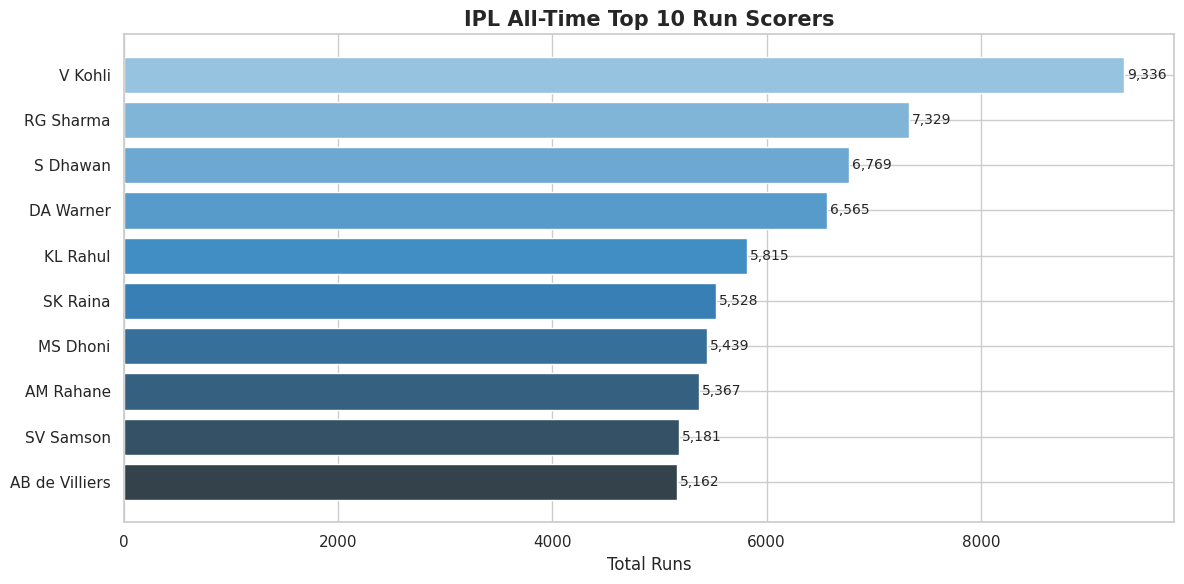

In [42]:
# Plotting the top 10 run scorers
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Blues_d', len(top_scorers))
bars = ax.barh(top_scorers['batter'], top_scorers['total_runs'], color=colors)

for bar, val in zip(bars, top_scorers['total_runs']):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Total Runs', fontsize=12)
ax.set_title('IPL All-Time Top 10 Run Scorers', fontsize=15, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

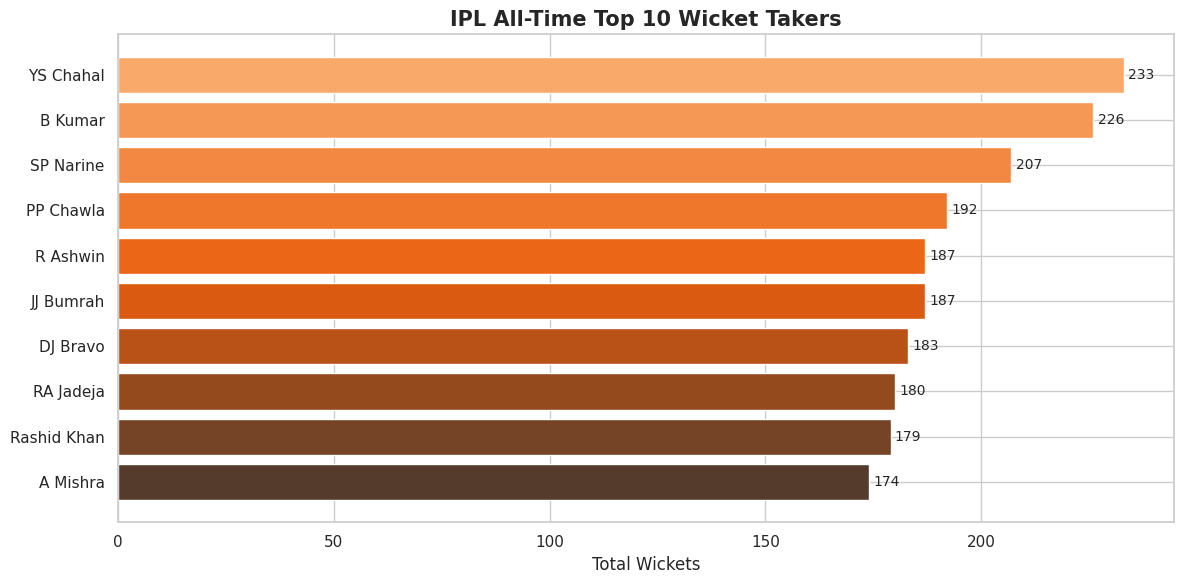

In [43]:
# Plotting the top 10 wicket takers
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Oranges_d', len(top_bowlers))
bars = ax.barh(top_bowlers['bowler'], top_bowlers['wickets'], color=colors)

for bar, val in zip(bars, top_bowlers['wickets']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Total Wickets', fontsize=12)
ax.set_title('IPL All-Time Top 10 Wicket Takers', fontsize=15, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

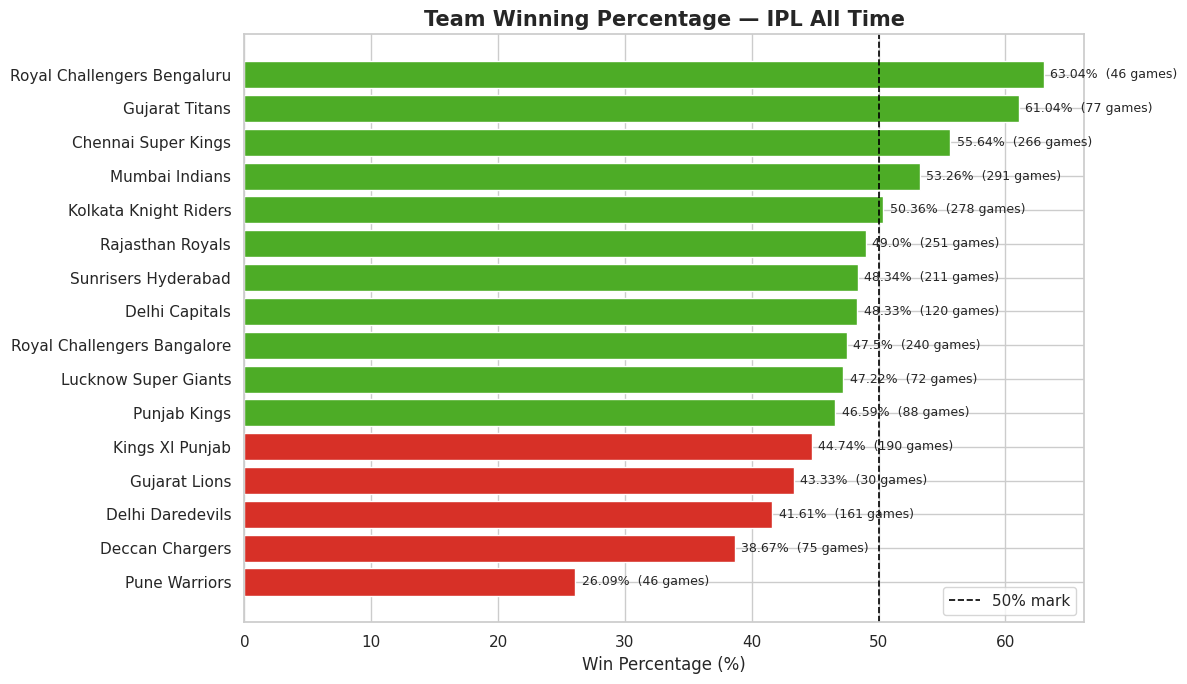

In [44]:
# Plotting team winning percentages for teams with at least 20 games played
plot_teams = team_stats[team_stats['total_games'] >= 20].sort_values('win_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#d73027' if w < 45 else '#4dac26' for w in plot_teams['win_pct']]
ax.barh(plot_teams.index, plot_teams['win_pct'], color=colors, edgecolor='white')
ax.axvline(50, color='black', linestyle='--', linewidth=1.2, label='50% mark')

for i, (val, games) in enumerate(zip(plot_teams['win_pct'], plot_teams['total_games'])):
    ax.text(val + 0.5, i, f'{val}%  ({int(games)} games)', va='center', fontsize=9)

ax.set_xlabel('Win Percentage (%)', fontsize=12)
ax.set_title('Team Winning Percentage — IPL All Time', fontsize=15, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

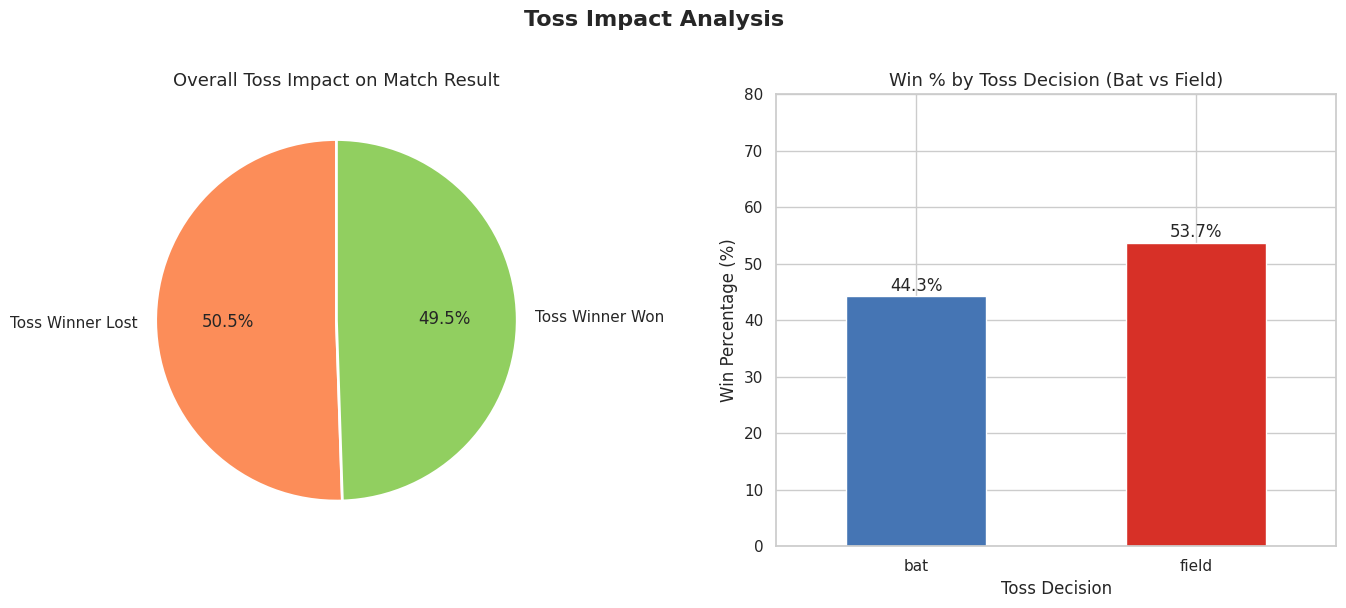

In [45]:
# Visualizing the impact of the toss on match results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart showing overall toss impact
toss_counts = matches['toss_match_win'].value_counts()
axes[0].pie(
    toss_counts,
    labels=['Toss Winner Lost', 'Toss Winner Won'],
    autopct='%1.1f%%',
    colors=['#fc8d59', '#91cf60'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Toss Impact on Match Result', fontsize=13)

# Bar plot showing win percentage by toss decision
toss_by_decision.plot(kind='bar', ax=axes[1], color=['#4575b4', '#d73027'], edgecolor='white', rot=0)
axes[1].set_ylabel('Win Percentage (%)')
axes[1].set_xlabel('Toss Decision')
axes[1].set_title('Win % by Toss Decision (Bat vs Field)', fontsize=13)
axes[1].set_ylim(0, 80)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=12)

plt.suptitle('Toss Impact Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

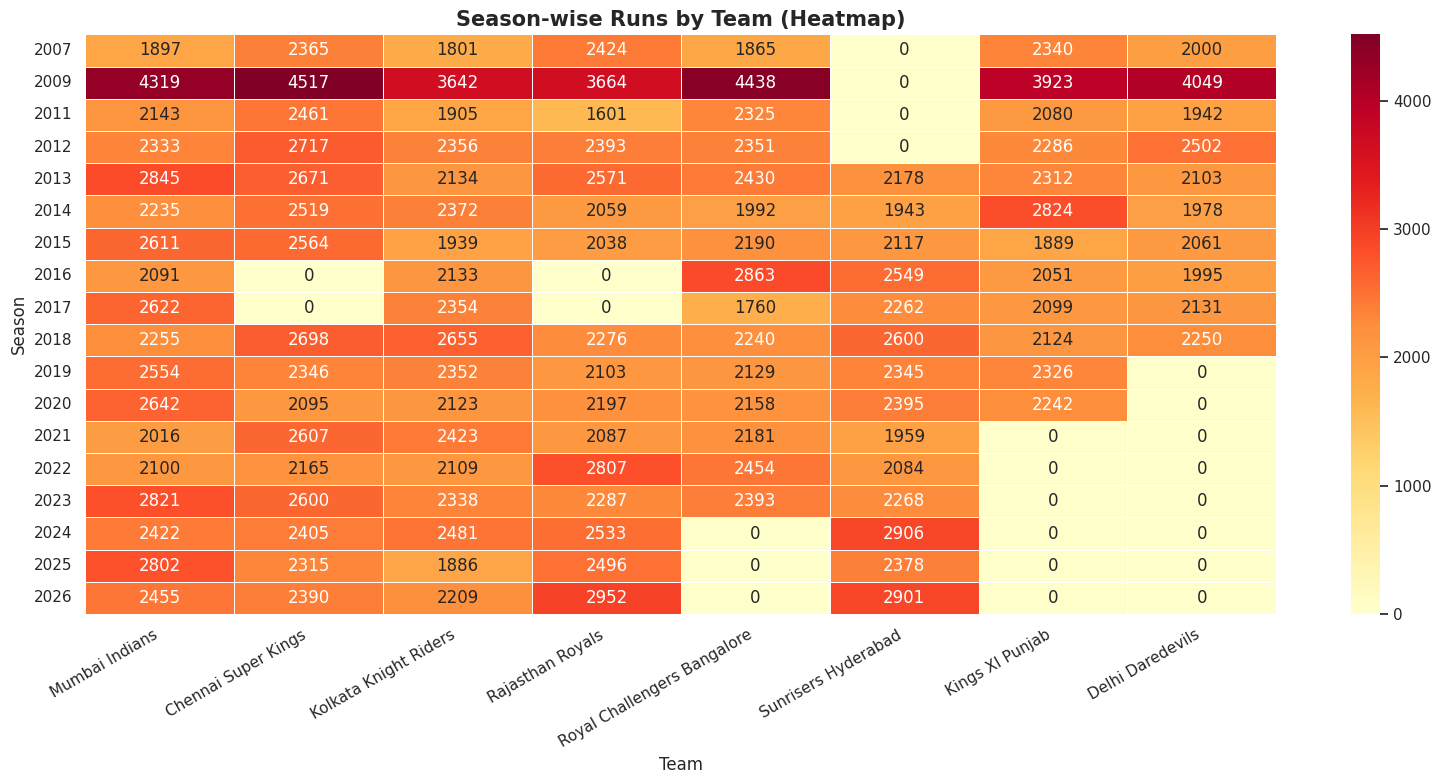

In [46]:
# Creating a heatmap to visualize season-wise runs by team from the pivot table
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot_display,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Season-wise Runs by Team (Heatmap)', fontsize=15, fontweight='bold')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Season', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 11. Conclusion

This analysis of IPL ball-by-ball data reveals several key insights:

| Finding | Insight |
|---|---|
| **Top Batter** | Virat Kohli consistently leads all-time run charts |
| **Top Bowler** | YS Chahal / B Kumar lead wicket counts across seasons |
| **Best Team Record** | Royal Challengers Bengaluru / Gujarat Titans have high win percentages among active teams |
| **Toss Impact** | Winning the toss provides a marginal advantage (~50.5%) — not decisively influencing the outcome |
| **Toss Decision** | Teams opting to field after winning the toss have a slightly better win rate |

And that's a wrap on our IPL data analysis! 🏏